In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [3]:

df = pd.read_excel(r"C:\Users\ivans\Desktop\All\MSC\Data_Processsing\assignement\air_quality_analysis\data\processed\feature_engineered_air_quality_data.xlsx")

required_columns = [
    "country_name",
    "city",
    "year",
    "pm10_concentration",
    "pm25_concentration",
    "no2_concentration",
    "latitude",
    "longitude",
    "air_quality_level",
    "log_pm10_concentration",
    "log_no2_concentration",
    "absolute_latitude",
    "hemisphere",
    "longitude_direction",
    "latitude_zone"
]

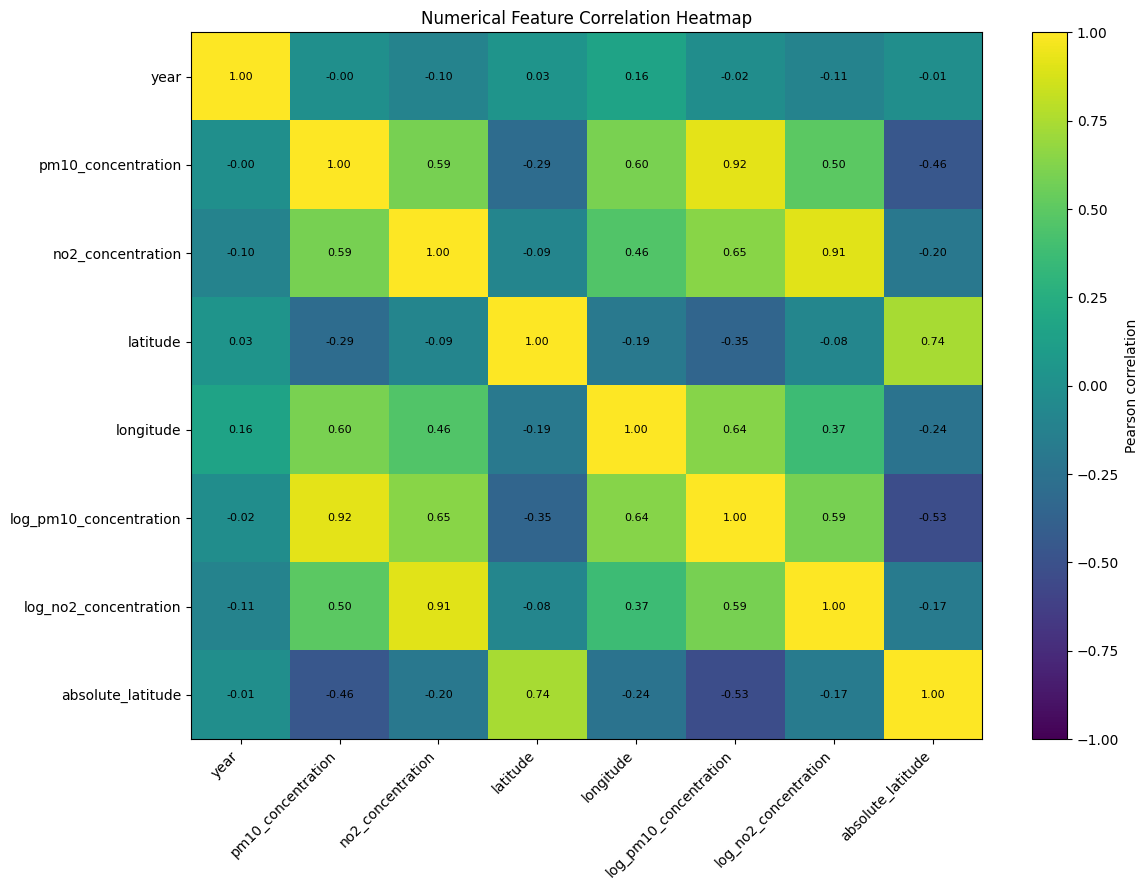

In [ ]:
numeric_candidates = [
    "year",
    "pm10_concentration",
    "no2_concentration",
    "latitude",
    "longitude",
    "log_pm10_concentration",
    "log_no2_concentration",
    "absolute_latitude"
]

numeric_corr = df[numeric_candidates].corr()

plt.figure(figsize=(12, 9))

image = plt.imshow(
    numeric_corr.to_numpy(),
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    image,
    label="Correlation"
)

plt.xticks(
    range(len(numeric_candidates)),
    numeric_candidates,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_candidates)),
    numeric_candidates
)

for row in range(len(numeric_candidates)):
    for column in range(len(numeric_candidates)):
        plt.text(
            column,
            row,
            f"{numeric_corr.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [5]:
high_correlation_pairs = []

for first_index, first_feature in enumerate(
    numeric_candidates
):
    for second_index in range(
        first_index + 1,
        len(numeric_candidates)
    ):
        second_feature = numeric_candidates[second_index]

        correlation = numeric_corr.loc[
            first_feature,
            second_feature
        ]

        if abs(correlation) >= 0.85:
            high_correlation_pairs.append({
                "Feature 1": first_feature,
                "Feature 2": second_feature,
                "Correlation": correlation
            })

high_correlation_table = pd.DataFrame(
    high_correlation_pairs
)

print("Strongly correlated feature pairs:")
print(high_correlation_table.round(3))

Strongly correlated feature pairs:
            Feature 1               Feature 2  Correlation
0  pm10_concentration  log_pm10_concentration        0.918
1   no2_concentration   log_no2_concentration        0.907


In [8]:
regular_model_features = [
    "country_name",
    "year",
    "pm10_concentration",
    "no2_concentration",
    "latitude",
    "longitude"
]

pca_model_features = [
    "year",
    "log_pm10_concentration",
    "no2_concentration",
    "latitude",
    "longitude"
]

target_column = "air_quality_level"

print("Selected features for regular models:")
print(regular_model_features)

print("\nSelected features for PCA/scaled models:")
print(pca_model_features)

print("\nTarget:")
print(target_column)

Selected features for regular models:
['country_name', 'year', 'pm10_concentration', 'no2_concentration', 'latitude', 'longitude']

Selected features for PCA/scaled models:
['year', 'log_pm10_concentration', 'no2_concentration', 'latitude', 'longitude']

Target:
air_quality_level


In [ ]:
regular_selected_data = df[
    regular_model_features + [target_column]
].copy()

pca_selected_data = df[
    pca_model_features + [target_column]
].copy()

print("Regular selected-data shape:")
print(regular_selected_data.shape)

print("\nPCA selected-data shape:")
print(pca_selected_data.shape)

Regular selected-data shape:
(21729, 7)

PCA selected-data shape:
(21729, 6)
